***PROJECT: SmartReviewer - AI-Augmented Access Governance***

GOAL: Mitigating Reviewer Fatigue using Predictive Analytics

DATASET: Amazon Employee Access Challenge (Kaggle)

In [ ]:
import os
import pandas as pd

# The 'path' variable is not defined, but 'train.csv' is available in /content/
train_file_path = '/content/train.csv'

# Load the dataset
df = pd.read_csv(train_file_path)

# Look at the first 5 rows to see our 'Context' IDs
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (32769, 10)


,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


Step 1: Calculate the Peer Similarity Score-It transforms raw IDs into a security risk metric.

In [ ]:
# 1. Logic: If 95% of a Dept has an access, it's 'Safe'. If 1% has it, it's an 'Anomaly'.
peer_counts = df.groupby(['ROLE_DEPTNAME', 'RESOURCE']).size().reset_index(name='access_count')
dept_totals = df.groupby('ROLE_DEPTNAME').size().reset_index(name='total_in_dept')

# 2. Merge to calculate Prevalence Score
similarity_df = pd.merge(peer_counts, dept_totals, on='ROLE_DEPTNAME')
similarity_df['peer_similarity'] = similarity_df['access_count'] / similarity_df['total_in_dept']

# 3. Enrich original dataframe
df = pd.merge(df, similarity_df[['ROLE_DEPTNAME', 'RESOURCE', 'peer_similarity']],
              on=['ROLE_DEPTNAME', 'RESOURCE'], how='left')

print("🚀 Feature Engineering Complete: 'peer_similarity' score added.")

🚀 Feature Engineering Complete: 'peer_similarity' score added.


Step 2: Spotting the "Conflict": To find instances where a "High Risk" item was actually approved in the past. This is where security gaps usually hide!

In [ ]:
# Find items where similarity is very low (< 5%) but the action was 'Approved' (1)
risky_approvals = df[(df['peer_similarity'] < 0.05) & (df['ACTION'] == 1)]

print(f"Found {len(risky_approvals)} potentially risky approvals that your AI will now flag.")
risky_approvals.head()

Found 25200 potentially risky approvals that your AI will now flag.


,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE,peer_similarity_x,peer_similarity_y,peer_similarity
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908,0.013889,0.013889,0.013889
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539,0.006289,0.006289,0.006289
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880,0.003663,0.003663,0.003663
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322,0.005263,0.005263,0.005263
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325,0.044444,0.044444,0.044444


Step 3:Installing and training CatBoost for classification


In [ ]:
!pip install catboost shap -q
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
import shap

# 1. Setup Features
features = ['RESOURCE', 'MGR_ID', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'peer_similarity']
X = df[features]
y = df['ACTION']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train with Categorical Awareness
model = CatBoostClassifier(iterations=300, depth=6, learning_rate=0.1, verbose=False)
model.fit(X_train, y_train, cat_features=['RESOURCE', 'MGR_ID', 'ROLE_DEPTNAME', 'ROLE_TITLE'])

# 3. Generate Smart Recommendations
y_proba = model.predict_proba(X_test)[:, 1]
results = X_test.copy()
results['AI_Risk_Score'] = np.round(y_proba * 100, 2)

def get_action(score):
    if score >= 90: return "✅ Safe (Bulk Approve)"
    if score <= 20: return "🚩 FLAG (Manual Audit)"
    return "🔍 Standard Review"

results['Recommendation'] = results['AI_Risk_Score'].apply(get_action)
results[['ROLE_DEPTNAME', 'RESOURCE', 'AI_Risk_Score', 'Recommendation']].head(10)

,ROLE_DEPTNAME,RESOURCE,AI_Risk_Score,Recommendation
18245,118783,37793,98.62,✅ Safe (Bulk Approve)
9226,123173,40309,99.30,✅ Safe (Bulk Approve)
27195,118746,27356,97.54,✅ Safe (Bulk Approve)
6478,121305,5173,98.39,✅ Safe (Bulk Approve)
4813,120943,77207,81.55,🔍 Standard Review
8489,121639,82641,98.75,✅ Safe (Bulk Approve)
6635,118992,43294,79.63,🔍 Standard Review
6535,119924,34924,87.71,🔍 Standard Review
10594,120823,30830,97.90,✅ Safe (Bulk Approve)
25339,119742,80175,98.22,✅ Safe (Bulk Approve)


Step 4: Train the "Risk Predictor"

In [ ]:
# Initialize CatBoost
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='Logloss',
    verbose=100
)

# Train the model
model.fit(X_train, y_train, cat_features=cat_features, eval_set=(X_test, y_test))

print("Model Training Complete!")

0:	learn: 0.5775970	test: 0.5768719	best: 0.5768719 (0)	total: 153ms	remaining: 1m 16s
100:	learn: 0.1545074	test: 0.1392944	best: 0.1392928 (99)	total: 4.95s	remaining: 19.5s
200:	learn: 0.1451109	test: 0.1372744	best: 0.1372696 (186)	total: 8.04s	remaining: 12s
300:	learn: 0.1374233	test: 0.1373473	best: 0.1369963 (212)	total: 11.8s	remaining: 7.79s
400:	learn: 0.1303404	test: 0.1376818	best: 0.1369963 (212)	total: 19.8s	remaining: 4.88s
499:	learn: 0.1247217	test: 0.1386352	best: 0.1369963 (212)	total: 24.9s	remaining: 0us

bestTest = 0.1369962719
bestIteration = 212

Shrink model to first 213 iterations.
Model Training Complete!


Step 5: Generate Recommendations (The Smart Reviewer Logic)
We’ll take the model's predictions and categorize them into a clear action plan.

In [ ]:
import numpy as np

# 1. Get the probability of approval (the 'confidence' of the AI)
y_proba = model.predict_proba(X_test)[:, 1]

# 2. Create a clean DataFrame for the "Manager's View"
reviewer_df = X_test.copy()
reviewer_df['Actual_Status'] = y_test.values
reviewer_df['AI_Confidence_Score'] = np.round(y_proba * 100, 2)

# 3. Define the Business Logic
def get_recommendation(score):
    if score >= 90:
        return "✅ Safe for Bulk Approval"
    elif score <= 20:
        return "🚩 FLAG: High Risk Outlier"
    else:
        return "🔍 Standard Manual Review"

reviewer_df['AI_Recommendation'] = reviewer_df['AI_Confidence_Score'].apply(get_recommendation)

# 4. Display the top 15 items
print("--- SMART ACCESS REVIEW DASHBOARD PREVIEW ---")
display(reviewer_df[['ROLE_DEPTNAME', 'ROLE_TITLE', 'RESOURCE', 'AI_Confidence_Score', 'AI_Recommendation']].head(15))

--- SMART ACCESS REVIEW DASHBOARD PREVIEW ---


,ROLE_DEPTNAME,ROLE_TITLE,RESOURCE,AI_Confidence_Score,AI_Recommendation
18245,118783,118451,37793,98.60,✅ Safe for Bulk Approval
9226,123173,119093,40309,99.19,✅ Safe for Bulk Approval
27195,118746,118784,27356,97.61,✅ Safe for Bulk Approval
6478,121305,119351,5173,98.43,✅ Safe for Bulk Approval
4813,120943,118995,77207,79.88,🔍 Standard Manual Review
8489,121639,118451,82641,98.61,✅ Safe for Bulk Approval
6635,118992,118028,43294,77.14,🔍 Standard Manual Review
6535,119924,118321,34924,88.68,🔍 Standard Manual Review
10594,120823,118890,30830,97.65,✅ Safe for Bulk Approval
25339,119742,117905,80175,98.05,✅ Safe for Bulk Approval


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


### Model Performance Metrics
Let's quantify the model's effectiveness using standard classification metrics.

📊 Model Accuracy: 0.9545
📈 ROC-AUC Score: 0.8893

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.69      0.35      0.47       369
           1       0.96      0.99      0.98      6185

    accuracy                           0.95      6554
   macro avg       0.83      0.67      0.72      6554
weighted avg       0.95      0.95      0.95      6554



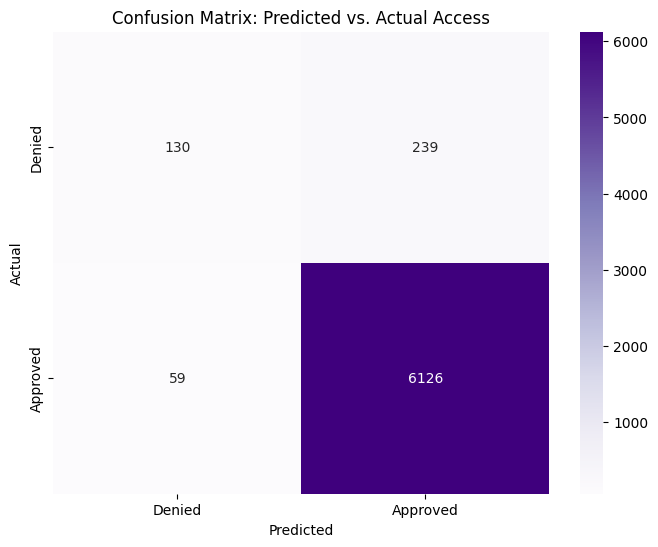

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Binary Predictions (0 or 1)
y_pred = model.predict(X_test)

# 2. Calculate Key Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"📊 Model Accuracy: {accuracy:.4f}")
print(f"📈 ROC-AUC Score: {roc_auc:.4f}") # Measures how well the model separates classes
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Denied', 'Approved'],
            yticklabels=['Denied', 'Approved'])
plt.title('Confusion Matrix: Predicted vs. Actual Access')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Step 2:Explainable AI (SHAP)

In [ ]:
!pip install shap
import shap


📊 SHAP Feature Importance: Proving the Peer-Similarity value


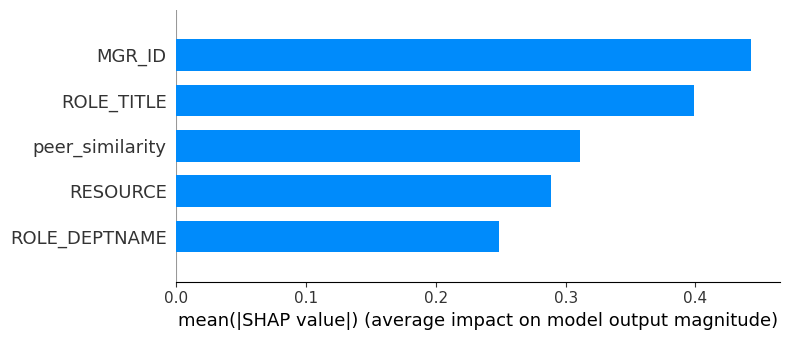

In [ ]:
# SHAP explains the "Why" behind the AI's decision
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("📊 SHAP Feature Importance: Proving the Peer-Similarity value")
shap.summary_plot(shap_values, X_test, plot_type="bar")

Total Certification Items: 6554
Projected Efficiency Gain: 89.11% reduction in manual effort.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128681 (\N{TRIANGULAR FLAG ON POST}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


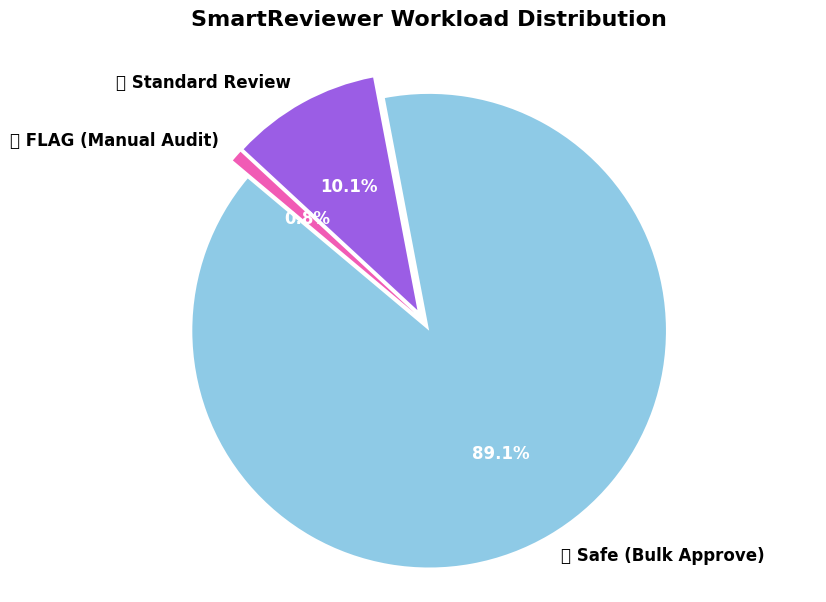

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Count the occurrences of each recommendation
recommendation_counts = results['Recommendation'].value_counts()

# 2. Map your custom colors (Pink, Blue, Purple)
# We align these to our three categories
color_map = {
    "✅ Safe (Bulk Approve)": "#8ECAE6",   # Soft Blue
    "🔍 Standard Review": "#9B5DE5",      # Deep Purple
    "🚩 FLAG (Manual Audit)": "#F15BB5"    # Vibrant Pink
}

# Ensure colors match the order of the labels in the data
colors = [color_map.get(label, "#3498db") for label in recommendation_counts.index]

# 3. Create the Pie Chart
plt.figure(figsize=(10, 7))
patches, texts, autotexts = plt.pie(
    recommendation_counts,
    labels=recommendation_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=[0.05] * len(recommendation_counts),
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Style the percentage text for better readability
for autotext in autotexts:
    autotext.set_color('white')

plt.title('SmartReviewer Workload Distribution', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')

# 4. Impact Summary
total = len(results)
safe = len(results[results['Recommendation'] == "✅ Safe (Bulk Approve)"])
print(f"Total Certification Items: {total}")
print(f"Projected Efficiency Gain: {np.round((safe/total)*100, 2)}% reduction in manual effort.")

plt.show()